# 온라인 제품 판매량 예측 모델 (Advanced Sales Prediction)

본 노트북은 과거 제품 판매량과 브랜드 검색량 데이터를 기반으로 향후 제품 판매량을 예측하는 모델링 프로젝트입니다.

## 1. 데이터셋 컬럼별 설명

### train.csv
- **ID**: 제품별 고유 식별자
- **제품**: 제품 코드
- **대분류/중분류/소분류**: 제품 계층 구조

|**단계**|**명칭**|**예시 (가전)**|**예시 (식품)**|**특징**|
|---|---|---|---|---|
|**대분류**|`C001`|**주방가전**|**가공식품**|가장 큰 산업군 또는 제품군|
|**중분류**|`C002`|전자레인지|라면/면류|대분류를 용도별로 쪼갠 것|
|**소분류**|`C003`|복합오븐레인지|컵라면|실제 구매하는 구체적 품목|

- **브랜드**: 제품의 브랜드 정보
- **2022-01-01 ~ 2023-04-04**: 일별 판매량

### brand_keyword_cnt.csv
- **브랜드**: 브랜드 정보
- **2022-01-01 ~ 2023-04-04**: 일별 해당 브랜드의 검색 빈도 (정규화됨)

### product_info.csv
- **제품**: 제품 코드
- **제품특성**: 제품의 상세 스펙/설명 (텍스트 데이터)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU
from tensorflow.keras.callbacks import EarlyStopping
import warnings

warnings.filterwarnings('ignore')
plt.rc('font', family='Malgun Gothic') # Windows 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

## 2. 데이터 로드 및 초기 탐색

In [2]:
train = pd.read_csv('./data/train.csv')
brend_keyword = pd.read_csv('./data/brand_keyword_cnt.csv')
product_info = pd.read_csv('./data/product_info.csv')

print(f"Train Data: {train.shape}")
print(f"brend_keyword Data: {brend_keyword.shape}")
print(f"Product Info: {product_info.shape}")
display(train.head(3))

Train Data: (15890, 465)
brend_keyword Data: (3170, 460)
Product Info: (12778, 2)


,ID,제품,대분류,중분류,소분류,브랜드,2022-01-01,2022-01-02,2022-01-03,2022-01-04,...,2023-03-26,2023-03-27,2023-03-28,2023-03-29,2023-03-30,2023-03-31,2023-04-01,2023-04-02,2023-04-03,2023-04-04
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,B002-00002-00001,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,1,3,2,0,0,2,0
2,2,B002-00002-00002,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
sales = pd.read_csv('./data/sales.csv')
print(f"Sales Data Shape: {sales.shape}")
display(sales.head(5))

Sales Data Shape: (15890, 465)


,ID,제품,대분류,중분류,소분류,브랜드,2022-01-01,2022-01-02,2022-01-03,2022-01-04,...,2023-03-26,2023-03-27,2023-03-28,2023-03-29,2023-03-30,2023-03-31,2023-04-01,2023-04-02,2023-04-03,2023-04-04
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,B002-00002-00001,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,22400,67200,44800,0,0,44800,0
2,2,B002-00002-00002,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,B002-00002-00003,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,B002-00003-00001,B002-C001-0001,B002-C002-0001,B002-C003-0003,B002-00003,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# sales.csv 로드 (경로 확인하세요!)
sales = pd.read_csv('./data/sales.csv')

# sales에는 있지만 train에는 없는 컬럼 찾기
diff_cols = set(sales.columns) - set(train.columns)
print(f"sales.csv에만 있는 컬럼: {diff_cols}")

# 반대로 train에만 있는 컬럼이 있는지도 확인
diff_cols_train = set(train.columns) - set(sales.columns)
print(f"train.csv에만 있는 컬럼: {diff_cols_train}")

sales.csv에만 있는 컬럼: set()
train.csv에만 있는 컬럼: set()


In [5]:
# 두 데이터의 마지막 5개 컬럼명만 직접 비교해봅시다
print("--- train 마지막 컬럼 5개 ---")
print(train.columns[-5:].tolist())

print("\n--- sales 마지막 컬럼 5개 ---")
print(sales.columns[-5:].tolist())

# 행(가로)과 열(세로) 다시 한번 확인
print(f"\n[최종 확인] Train: {train.shape} / Sales: {sales.shape}")

--- train 마지막 컬럼 5개 ---
['2023-03-31', '2023-04-01', '2023-04-02', '2023-04-03', '2023-04-04']

--- sales 마지막 컬럼 5개 ---
['2023-03-31', '2023-04-01', '2023-04-02', '2023-04-03', '2023-04-04']

[최종 확인] Train: (15890, 465) / Sales: (15890, 465)


train.csv와 sales.csv는 동일한 데이터임을 확인할 수 있습니다.

In [6]:
print(train.info())

<class 'pandas.DataFrame'>
RangeIndex: 15890 entries, 0 to 15889
Columns: 465 entries, ID to 2023-04-04
dtypes: int64(460), str(5)
memory usage: 56.4 MB
None


In [34]:
# 첫 번째 제품의 정보를 제외한 실제 판매량 흐름만 보기
print(train.iloc[0, 5:])

브랜드            B002-00001
2022-01-01              0
2022-01-02              0
2022-01-03              0
2022-01-04              0
                  ...    
2023-04-02              0
2023-04-03              0
2023-04-04              0
total_sum             343
total_sales           343
Name: 0, Length: 462, dtype: object


In [7]:
# 전체 데이터 중 0의 비율 확인 (날짜 컬럼 대상)
date_cols = train.columns[6:]
total_elements = train[date_cols].size
zero_count = (train[date_cols] == 0).sum().sum()

print(f"전체 판매 데이터 중 0의 개수: {zero_count}")
print(f"전체 대비 0의 비중: {zero_count / total_elements * 100:.2f}%")

전체 판매 데이터 중 0의 개수: 4652860
전체 대비 0의 비중: 63.79%


0의 비중이 63.79%로 매우 많은 비중을 차지함을 알 수 있습니다.

In [6]:
train['대분류'].value_counts()

대분류
B002-C001-0002    10954
B002-C001-0001     3768
B002-C001-0005      613
B002-C001-0003      444
B002-C001-0004      111
Name: count, dtype: int64

전체 제품은 총 5개의 대분류로 구성되어 있으며, 카테고리별 제품 수 차이가 매우 큽니다.<br> 특히 B002-C001-0002 대분류가 10,954개로 전체 제품(15,890개)의 약 69%를 차지하는 압도적인 주력 카테고리임을 확인했습니다.

In [41]:
# 결측치 비율(%) 계산
null_counts = train.isnull().sum()
null_percentage = (null_counts / len(train)) * 100
print(null_counts)

ID             0
제품             0
대분류            0
중분류            0
소분류            0
              ..
2023-04-02     0
2023-04-03     0
2023-04-04     0
total_sum      0
total_sales    0
Length: 467, dtype: int64


## 3. 탐색적 데이터 분석 (EDA)

### 3.1 대분류별 제품 분포

In [7]:
# 대분류 비율 확인 (상위 20개)
mid_category_ratio = train['대분류'].value_counts(normalize=True).head(20) * 100
mid_category_count = train['대분류'].value_counts().head(20)

mid_df = pd.DataFrame({
    '개수': mid_category_count,
    '비율(%)': mid_category_ratio.round(2)
})
print("--- 대분류 상위 20개 비율 ---")
print(mid_df)

print("\n" + "="*30 + "\n")

# 브랜드 비율 확인 (상위 20개)
brand_ratio = train['브랜드'].value_counts(normalize=True).head(20) * 100
brand_count = train['브랜드'].value_counts().head(20)

brand_df = pd.DataFrame({
    '개수': brand_count,
    '비율(%)': brand_ratio.round(2)
})
print("--- 브랜드 상위 20개 비율 ---")
print(brand_df)

--- 대분류 상위 20개 비율 ---
                   개수  비율(%)
대분류                         
B002-C001-0002  10954  68.94
B002-C001-0001   3768  23.71
B002-C001-0005    613   3.86
B002-C001-0003    444   2.79
B002-C001-0004    111   0.70


--- 브랜드 상위 20개 비율 ---
             개수  비율(%)
브랜드                   
B002-00266  153   0.96
B002-00894  153   0.96
B002-00680  148   0.93
B002-00434  136   0.86
B002-02052  113   0.71
B002-02123   94   0.59
B002-02227   94   0.59
B002-02439   91   0.57
B002-01545   90   0.57
B002-02455   89   0.56
B002-03417   88   0.55
B002-01138   86   0.54
B002-00669   78   0.49
B002-01851   78   0.49
B002-01905   76   0.48
B002-02492   76   0.48
B002-01220   72   0.45
B002-02370   72   0.45
B002-02372   72   0.45
B002-03262   70   0.44


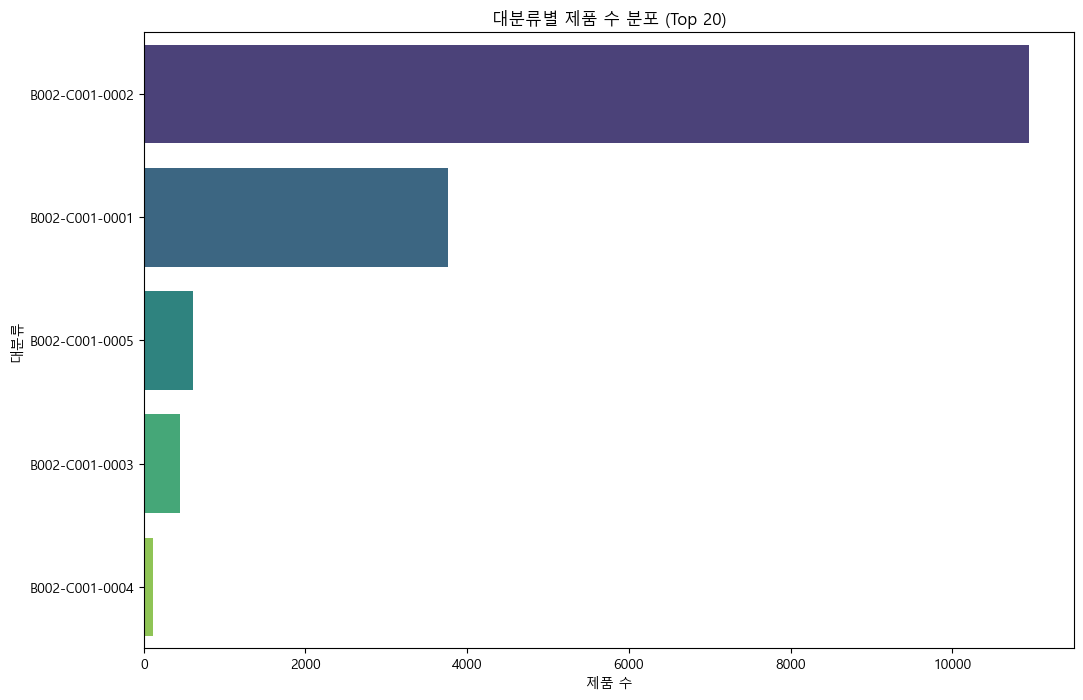

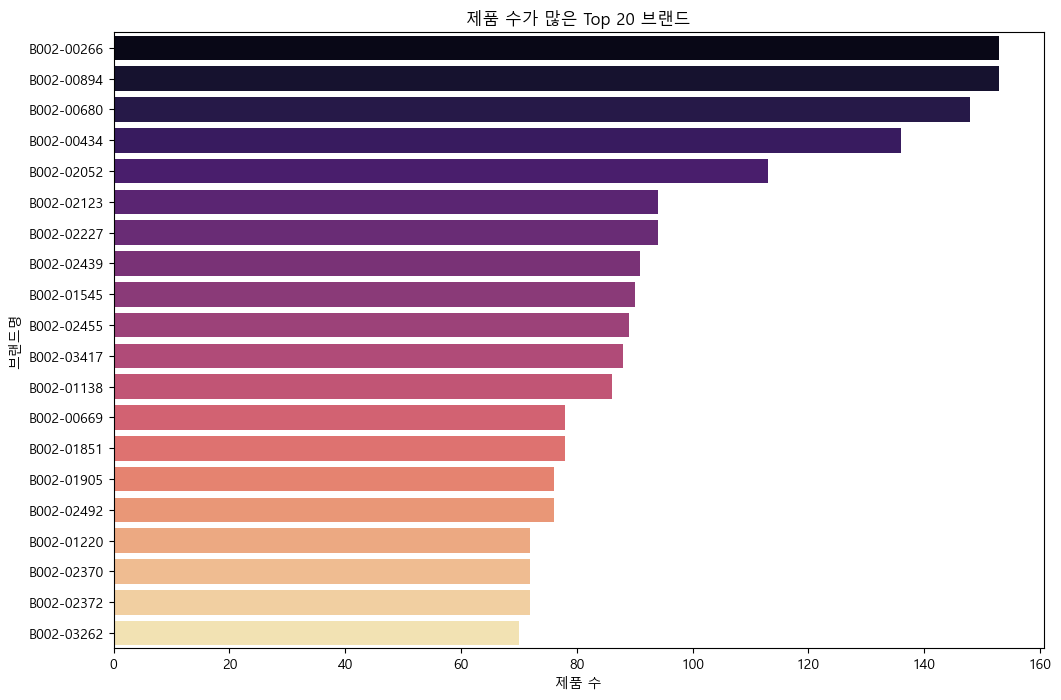

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 대분류별 제품 수 분포 시각화
plt.figure(figsize=(12, 8)) 
sns.countplot(data=train, y='대분류', order=train['대분류'].value_counts().index[:20], palette='viridis')
plt.title('대분류별 제품 수 분포 (Top 20)')
plt.xlabel('제품 수')
plt.ylabel('대분류')
plt.show()

# 제품 수가 많은 Top 20 브랜드
top_20_brands = train['브랜드'].value_counts().head(20)
plt.figure(figsize=(12, 8))
sns.barplot(x=top_20_brands.values, y=top_20_brands.index, palette='magma')
plt.title('제품 수가 많은 Top 20 브랜드')
plt.xlabel('제품 수')
plt.ylabel('브랜드명')
plt.show()

### 3.2 대분류별 판매량
대분류별로 일일 평균 판매량을 시각화하여 판매 패턴의 차이를 확인합니다.

In [9]:
# 각 제품별로 전체 기간의 판매량 합계 계산
date_cols = train.columns[6:]
train['total_sum'] = train[date_cols].sum(axis=1)

# 대분류별로 전체 판매량 합산
cat_total_sales = train.groupby('대분류')['total_sum'].sum()

# 판매 점유율(%) 계산
cat_sales_ratio = (cat_total_sales / cat_total_sales.sum()) * 100

# 제품당 평균 판매량 계산 (작성하신 시각화 코드의 '평균' 기준값)
cat_avg_sales = train.groupby('대분류')['total_sum'].mean()

# 결과 데이터프레임 생성
summary_df = pd.DataFrame({
    '전체 판매량 합계': cat_total_sales.astype(int),
    '판매 점유율(%)': cat_sales_ratio.round(2),
    '제품당 평균 판매량': cat_avg_sales.round(2)
}).sort_values(by='전체 판매량 합계', ascending=False)

print("--- 대분류별 판매 기여도 분석 ---")
print(summary_df)

--- 대분류별 판매 기여도 분석 ---
                전체 판매량 합계  판매 점유율(%)  제품당 평균 판매량
대분류                                             
B002-C001-0002   87218401      67.72     7962.24
B002-C001-0001   35441662      27.52     9405.96
B002-C001-0005    4961560       3.85     8093.90
B002-C001-0003    1078827       0.84     2429.79
B002-C001-0004      85411       0.07      769.47


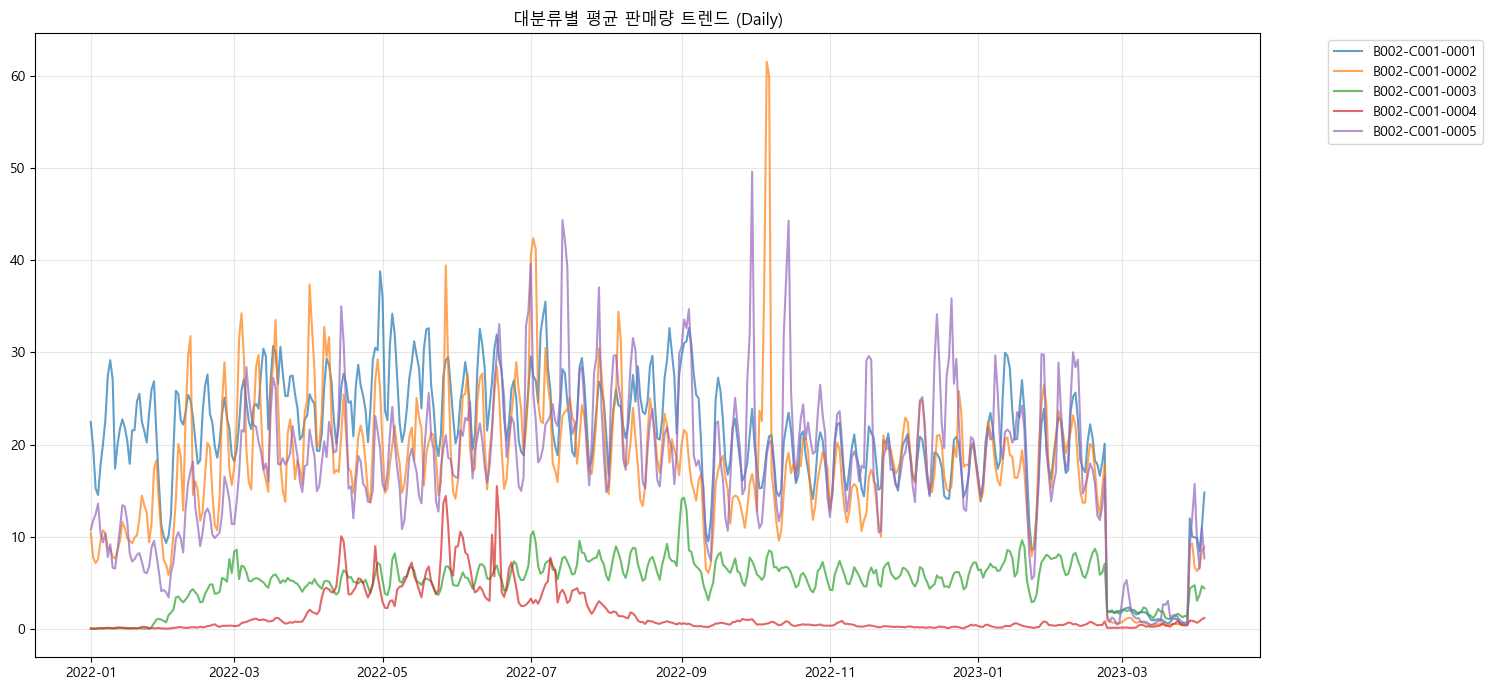

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

date_cols = [c for c in train.columns if str(c).startswith('20')]

# 대분류별 평균 판매량 계산
category_sales = train.groupby('대분류')[date_cols].mean().T

# 인덱스를 날짜형으로 변환
category_sales.index = pd.to_datetime(category_sales.index)

# 시각화
plt.figure(figsize=(15, 7))
for col in category_sales.columns:
    plt.plot(category_sales.index, category_sales[col], label=col, alpha=0.7)

plt.title('대분류별 평균 판매량 트렌드 (Daily)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.3 상위 5개 제품 판매량

In [17]:
import pandas as pd

# 날짜 컬럼만 정확하게 선택
# '20'으로 시작하는 날짜 컬럼들만 골라냅니다.
date_cols = [c for c in train.columns if str(c).startswith('20')]

# 제품별 전체 판매량 합계를 계산하여 새로운 컬럼으로 추가
train['total_sales'] = train[date_cols].sum(axis=1)

# 판매량(total_sales) 기준 상위 5개 제품 추출
top_5 = train.nlargest(5, 'total_sales')

# 결과 출력 (제품 ID, 대분류, 총 판매량)
print("--- 판매량 TOP 5 제품 리스트 ---")
display(top_5[['제품', '대분류', 'total_sales']])

--- 판매량 TOP 5 제품 리스트 ---


,제품,대분류,total_sales
485,B002-00113-00001,B002-C001-0001,3118885
11595,B002-02723-00004,B002-C001-0002,2595146
12336,B002-02920-00005,B002-C001-0002,2535587
4470,B002-01069-00002,B002-C001-0001,2008250
3481,B002-00809-00002,B002-C001-0002,1414800


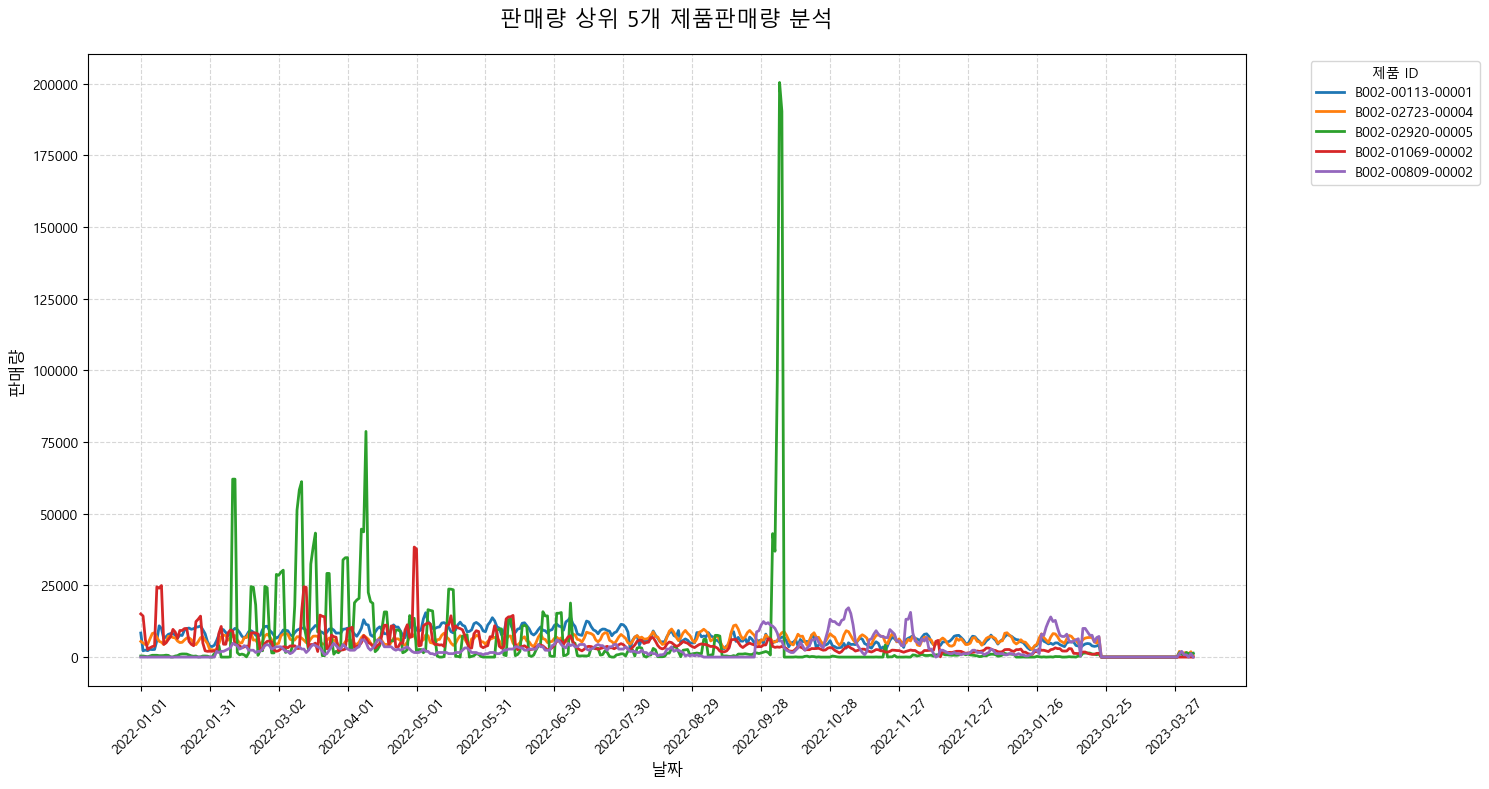

In [22]:
date_cols = [c for c in train.columns if str(c).startswith('20')]

top_5 = train.nlargest(5, 'total_sales').copy()

plt.figure(figsize=(15, 8))

for i, row in top_5.iterrows():
    
    product_id = row['제품'] 
    
    plt.plot(date_cols, row[date_cols], label=product_id, linewidth=2)

plt.title('판매량 상위 5개 제품판매량 분석', fontsize=16, pad=20)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('판매량', fontsize=12)

plt.xticks(date_cols[::30], rotation=45)

plt.legend(title='제품 ID', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 3.4 브랜드 검색량과 실제 판매량 상관관계
검색량이 판매의 선행 지표 역할을 하는지 확인해봅니다.

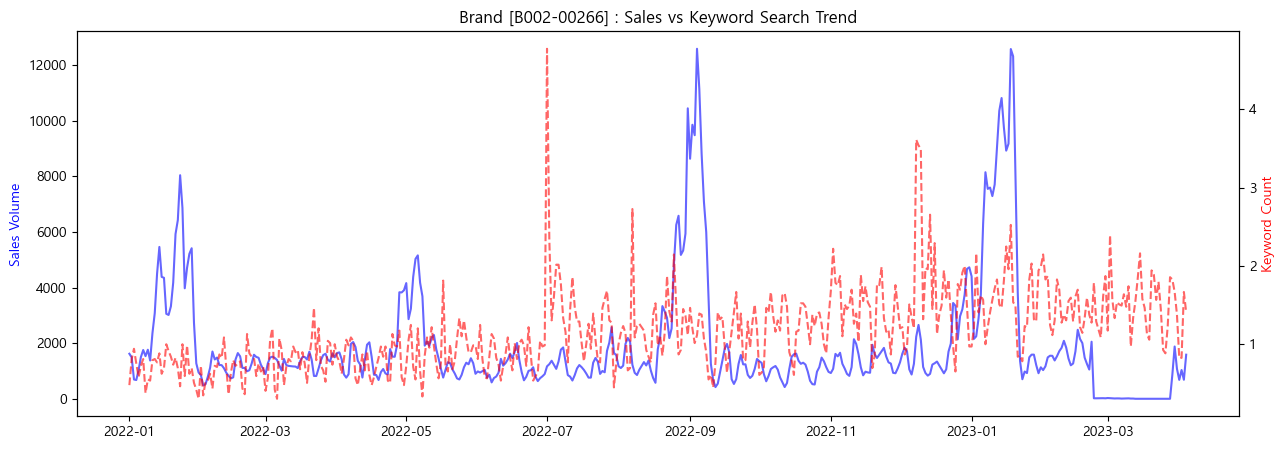

상관 계수: 0.0479


In [19]:
# 예시 브랜드 하나(가장 제품이 많은 브랜드)를 선택하여 분석
sample_brand = train['브랜드'].value_counts().index[0]

brand_sales = train[train['브랜드'] == sample_brand][date_cols].sum()
brand_keyword = brend_keyword[brend_keyword['브랜드'] == sample_brand][date_cols].sum()

fig, ax1 = plt.subplots(figsize=(15, 5))

ax1.plot(pd.to_datetime(date_cols), brand_sales, color='blue', label='Actual Sales', alpha=0.6)
ax1.set_ylabel('Sales Volume', color='blue')

ax2 = ax1.twinx()
ax2.plot(pd.to_datetime(date_cols), brand_keyword, color='red', linestyle='--', label='Keyword Search Count', alpha=0.6)
ax2.set_ylabel('Keyword Count', color='red')

plt.title(f'Brand [{sample_brand}] : Sales vs Keyword Search Trend')
plt.show()

corr = np.correlate(brand_sales, brand_keyword, mode='full')
print(f"상관 계수: {np.corrcoef(brand_sales, brand_keyword)[0,1]:.4f}")

### 3.5 Zero-Sales (판매 0일)
얼마나 많은 제품이 판매가 전혀 발생하지 않는 날이 있는지 확인하여 모델링의 난이도를 측정합니다.

전체 데이터 중 판매량이 0인 데이터의 비율: 63.79%


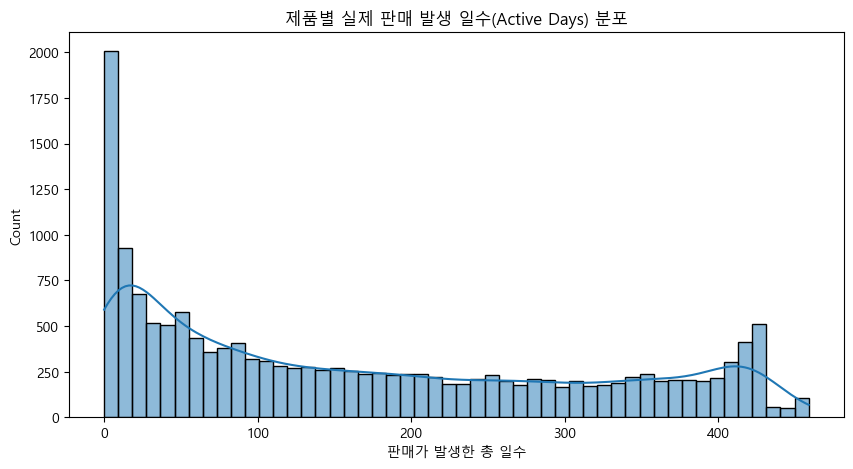

In [20]:
zero_sales_ratio = (train[date_cols] == 0).sum().sum() / (train[date_cols].size) * 100
print(f"전체 데이터 중 판매량이 0인 데이터의 비율: {zero_sales_ratio:.2f}%")

# 제품별 판매 발생 일수 분포
active_days = (train[date_cols] > 0).sum(axis=1)
plt.figure(figsize=(10, 5))
sns.histplot(active_days, bins=50, kde=True)
plt.title('제품별 실제 판매 발생 일수(Active Days) 분포')
plt.xlabel('판매가 발생한 총 일수')
plt.show()

## 4. 데이터 전처리 (Preprocessing)
효율적인 학습을 위해 데이터를 정제하고 3차원 텐서로 변환합니다.

In [ ]:
# 범주형 변수 처리
le = LabelEncoder()
for col in ['대분류', '중분류', '소분류', '브랜드']:
    train[col] = le.fit_transform(train[col])

# 스케일링
scaler = MinMaxScaler()
scaled_sales = scaler.fit_transform(train[date_cols].T).T # 제품별로 독립적 스케일링

print("Scaling Completed.")

## 5. 특성 공학 (Feature Engineering) & 시계열 데이터 생성
과거 28일 데이터를 보고 다음 1일을 예측하는 Windowing 방식을 적용합니다.

In [ ]:
def windowed_dataset(series, window_size=28):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

# 예시: 첫 번째 제품에 대한 데이터셋 생성
WINDOW_SIZE = 28
product_index = 0
series_data = scaled_sales[product_index]

X, y = windowed_dataset(series_data, WINDOW_SIZE)
X = X.reshape(-1, WINDOW_SIZE, 1)

print(f"X shape: {X.shape}, y shape: {y.shape}")

## 6. 모델링 (Keras GRU)
LSTM보다 학습 속도가 빠르고 성능이 준수한 GRU 모델을 사용합니다.

In [ ]:
model = Sequential([
    GRU(128, input_shape=(WINDOW_SIZE, 1), return_sequences=True),
    Dropout(0.2),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='huber', metrics=['mae'])
model.summary()

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X, y, epochs=100, batch_size=32, validation_split=0.2, callbacks=[es], verbose=0)
print("Training Done.")

## 7. 모델 평가 및 예측 (Evaluation & Predict)

In [ ]:
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

# 예측 테스트
last_days = series_data[-WINDOW_SIZE:].reshape(1, WINDOW_SIZE, 1)
prediction = model.predict(last_days)
inverse_prediction = scaler.inverse_transform([[prediction[0,0]]])

print(f"내일 예상 판매량: {inverse_prediction[0,0]:.2f} units")